In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
# Load sonar dataset
data = fetch_openml(name='sonar', version=1, as_frame=True)
X = data.data
y = data.target

# Encode target labels if they are not numeric
le = LabelEncoder()
y = le.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

# Train Logistic Regression
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# Predict probabilities
y_prob = model.predict_proba(X_test)[:, 1]

## Library ROC calculation

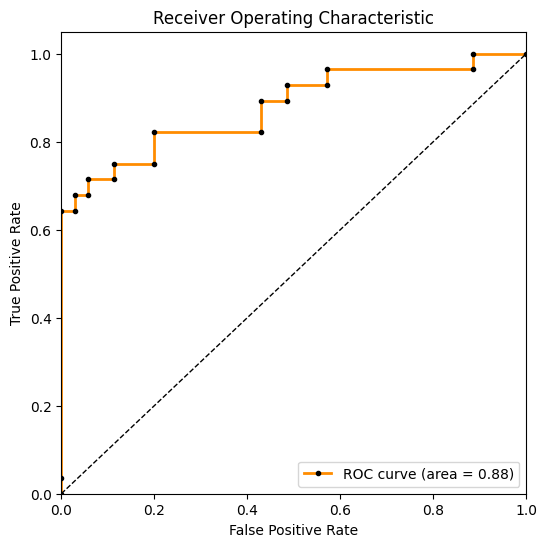

In [3]:
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6, 6))
plt.plot(
    fpr,
    tpr,
    lw=2,
    color='darkorange',
    marker='.',
    markerfacecolor='black',
    markeredgecolor='black',
    label=f'ROC curve (area = {roc_auc:.2f})'
)
plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

## Manual ROC calculation

In [4]:
# Sort the test labels and probabilities in descending order of probabilities
desc_score_indices = np.argsort(y_prob)[::-1]
y_test_sorted = y_test[desc_score_indices]

# Calculate cumulative positives and negatives
cum_pos = np.cumsum(y_test_sorted)
cum_neg = np.cumsum(1 - y_test_sorted)

# Total positives and negatives
total_pos = np.sum(y_test)
total_neg = len(y_test) - total_pos

In [5]:
# Sort the test labels and probabilities in descending order of probabilities
desc_score_indices = np.argsort(y_prob)[::-1]
y_test_sorted = y_test[desc_score_indices]

# Calculate cumulative positives and negatives
cum_pos = np.cumsum(y_test_sorted)
cum_neg = np.cumsum(1 - y_test_sorted)

# Total positives and negatives
total_pos = np.sum(y_test)
total_neg = len(y_test) - total_pos

tpr_vector = cum_pos / total_pos
fpr_vector = cum_neg / total_neg

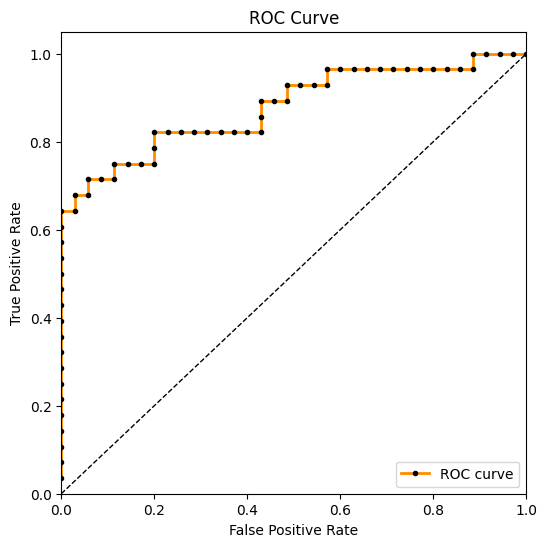

In [6]:
plt.figure(figsize=(6, 6))
plt.plot(
    fpr_vector,
    tpr_vector,
    color='darkorange',
    lw=2,
    marker='.',
    markerfacecolor='black',
    markeredgecolor='black',
    label='ROC curve'
)
plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Optimization

In [7]:
# set the initial point
prev_fpr, prev_tpr = 0., 0.
# set some null initial direction
prev_dir = ""
# initialize a list to store the points to be plotted [fpr, tpr].
plot_points = []
# iterate over the sorted points
for curr_tpr, curr_fpr in zip(tpr_vector, fpr_vector):
    # calculate the direction wrt. the prev fpr and tpr
    if (curr_tpr > prev_tpr):
        curr_dir = "up"
    elif (curr_fpr > prev_fpr):
        curr_dir = "right"
    else:
        curr_dir = "diagonal"

    # if the direction has changed, add the previous point to the list
    if curr_dir != prev_dir:
        plot_points.append([prev_fpr, prev_tpr])
        # update the previous direction
        prev_dir = curr_dir
    
    # update the previous fpr and tpr
    prev_fpr, prev_tpr = curr_fpr, curr_tpr

# add the last point to the list
plot_points.append([curr_fpr, curr_tpr])

# convert list to numpy array for plotting
plot_points = np.array(plot_points)

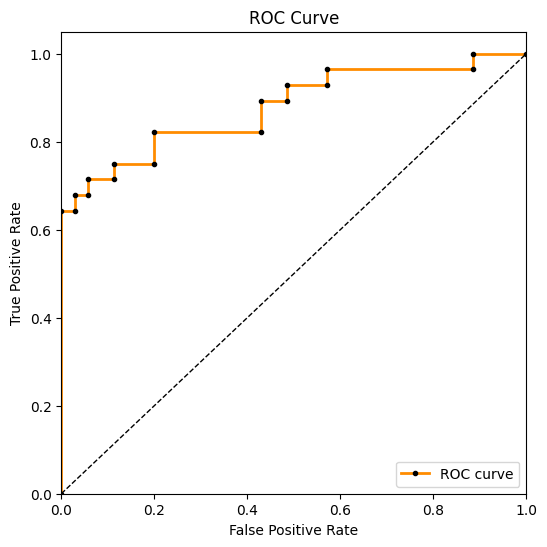

In [8]:
plt.figure(figsize=(6, 6))
plt.plot(
    plot_points[:, 0],
    plot_points[:, 1],
    color='darkorange',
    lw=2,
    marker='.',
    markerfacecolor='black',
    markeredgecolor='black',
    label='ROC curve'
)
plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()